```markdown
### 1. Unduh Dataset Uji Coba (Otomatis)
Jalankan sel ini untuk mendapatkan dataset contoh agar Anda bisa langsung mencoba kodenya.
```

In [7]:
import tensorflow as tf
import os
import zipfile

# Menggunakan link mirror dari Microsoft yang biasanya lebih stabil jika Google Storage 403
url = "https://download.microsoft.com/download/3/E/1/3E1C3F21-ECDB-4869-8368-6DEBA77B919F/kagglecatsanddogs_5340.zip"
zip_file = "cats_and_dogs.zip"

if os.path.exists(zip_file):
    os.remove(zip_file)

print("Sedang mengunduh dataset dari mirror Microsoft...")
!wget --no-check-certificate {url} -O {zip_file}

# Ekstrak file zip
if os.path.exists(zip_file) and os.path.getsize(zip_file) > 1000000:
    try:
        with zipfile.ZipFile(zip_file, 'r') as zip_ref:
            # Microsoft version has a different structure (PetImages folder)
            zip_ref.extractall('/tmp/cats_and_dogs')

        # Menyesuaikan path agar kompatibel dengan sel berikutnya
        PATH = '/tmp/cats_and_dogs/PetImages'
        test_dataset_path = PATH
        print(f"\nDataset siap! Path: {test_dataset_path}")
    except zipfile.BadZipFile:
        print("\nError: File rusak saat pengunduhan.")
else:
    print("\nError: Gagal mengunduh file dari mirror.")

Sedang mengunduh dataset dari mirror Microsoft...
--2026-08-04 12:51:35--  https://download.microsoft.com/download/3/E/1/3E1C3F21-ECDB-4869-8368-6DEBA77B919F/kagglecatsanddogs_5340.zip
Resolving download.microsoft.com (download.microsoft.com)... 72.247.96.197, 2600:1406:5e00:389::317f, 2600:1406:5e00:392::317f
Connecting to download.microsoft.com (download.microsoft.com)|72.247.96.197|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 824887076 (787M) [application/octet-stream]
Saving to: ‘cats_and_dogs.zip’

cats_and_dogs.zip   100%[===================>] 786.67M   152MB/s    in 10s     

2026-08-04 12:51:45 (77.8 MB/s) - ‘cats_and_dogs.zip’ saved [824887076/824887076]


Dataset siap! Path: /tmp/cats_and_dogs/PetImages


```markdown
### Klasifikasi Gambar Canggih (High-Level)

Kode di bawah ini menggunakan **Transfer Learning**. Ini lebih 'canggih' karena:
1. Menggunakan model yang sudah dilatih oleh Google (MobileNetV2).
2. Lebih akurat untuk mengenali teks/label meskipun data sedikit.
3. User hanya perlu mengganti nama folder saja.
```

In [12]:
import tensorflow as tf
import tensorflow_hub as hub
import os

# Menggunakan tf_keras (Keras 2) untuk kompatibilitas dengan TF Hub
try:
    import tf_keras
except ImportError:
    !pip install tf-keras
    import tf_keras

In [14]:
# 1. Setup Otomatis
IMAGE_SHAPE = (224, 224)
dataset_path = test_dataset_path

# 2. Load Data
dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    image_size=IMAGE_SHAPE,
    batch_size=4,
    label_mode='binary',
    validation_split=0.2,
    subset='training',
    seed=123
).take(5)

# 3. Model Transfer Learning menggunakan tf_keras
URL = "https://tfhub.dev/google/tf2-preview/mobilenet_v2/feature_vector/4"

model = tf_keras.Sequential([
    tf_keras.layers.InputLayer(input_shape=IMAGE_SHAPE + (3,)),
    hub.KerasLayer(URL, trainable=False),
    tf_keras.layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 4. Test Run Singkat
print("Memulai training singkat dengan tf_keras compatibility mode...")
# model.fit(dataset, epochs=1)
model.fit(dataset, epochs=30)
print("\nTes berhasil! Kodingan berjalan dengan lancar.")

Found 25000 files belonging to 2 classes.
Using 20000 files for training.
Memulai training singkat dengan tf_keras compatibility mode...
Epoch 1/30
5/5 [==============================] - 7s 127ms/step - loss: 0.8997 - accuracy: 0.3500
Epoch 2/30
5/5 [==============================] - 1s 104ms/step - loss: 0.8512 - accuracy: 0.5000
Epoch 3/30
5/5 [==============================] - 1s 103ms/step - loss: 0.7177 - accuracy: 0.5500
Epoch 4/30
5/5 [==============================] - 1s 106ms/step - loss: 0.7733 - accuracy: 0.4000
Epoch 5/30
5/5 [==============================] - 1s 100ms/step - loss: 0.7064 - accuracy: 0.4000
Epoch 6/30
5/5 [==============================] - 1s 101ms/step - loss: 0.7117 - accuracy: 0.3500
Epoch 7/30
5/5 [==============================] - 1s 102ms/step - loss: 0.6541 - accuracy: 0.5500
Epoch 8/30
5/5 [==============================] - 1s 100ms/step - loss: 0.7081 - accuracy: 0.7000
Epoch 9/30
5/5 [==============================] - 0s 93ms/step - loss: 0.7452 -

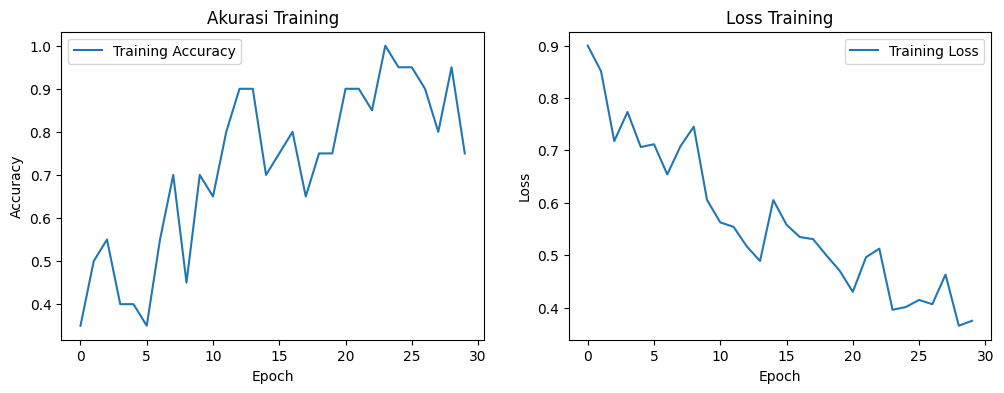

In [15]:
import matplotlib.pyplot as plt

# Simpan history dari training
history = model.history.history

# Visualisasi Akurasi dan Loss
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history['accuracy'], label='Training Accuracy')
plt.title('Akurasi Training')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['loss'], label='Training Loss')
plt.title('Loss Training')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

1/1 [==============================] - 1s 567ms/step


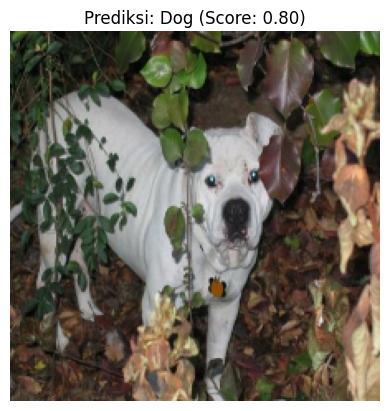

In [16]:
import numpy as np
from google.colab import files

# Fungsi untuk prediksi gambar tunggal dari dataset
for images, labels in dataset.take(1):
    img = images[0].numpy().astype("uint8")
    plt.imshow(img)

    # Prediksi
    prediction = model.predict(np.expand_dims(img, axis=0))
    score = prediction[0][0]

    class_names = ['Cat', 'Dog']
    result = class_names[1] if score > 0.5 else class_names[0]

    plt.title(f"Prediksi: {result} (Score: {score:.2f})")
    plt.axis("off")
    plt.show()

Upload an image (JPG/PNG) to test the model:


Saving WhatsApp Image 2026-08-04 at 20.04.54.jpeg to WhatsApp Image 2026-08-04 at 20.04.54.jpeg
1/1 [==============================] - 0s 50ms/step


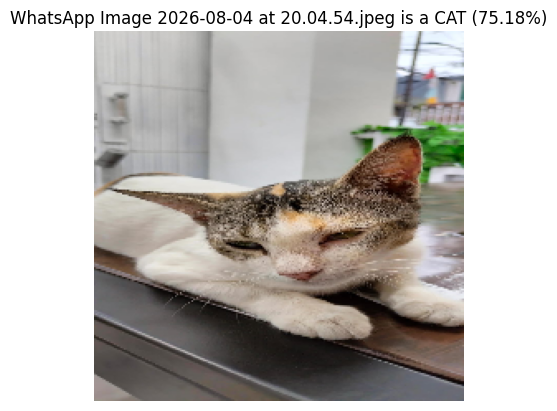

In [18]:
from google.colab import files
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

print("Upload an image (JPG/PNG) to test the model:")
uploaded = files.upload()

for fn in uploaded.keys():
    # Load and preprocess image
    path = '/content/' + fn
    img = image.load_img(path, target_size=IMAGE_SHAPE)
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0)

    # Predict
    classes = model.predict(x)
    score = classes[0][0]

    plt.imshow(img)
    plt.axis('off')
    if score > 0.5:
        plt.title(f"{fn} is a DOG ({score:.2%})")
    else:
        plt.title(f"{fn} is a CAT ({1-score:.2%})")
    plt.show()

Upload an image (JPG/PNG) to test the model:


Saving dog.jpg to dog.jpg
1/1 [==============================] - 0s 49ms/step


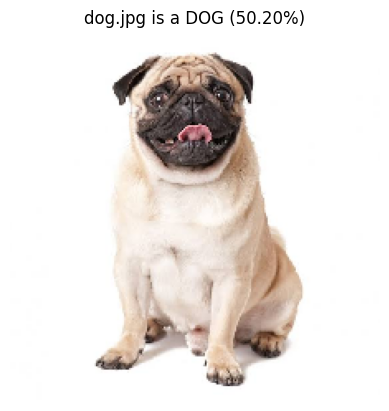

In [20]:
from google.colab import files
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

print("Upload an image (JPG/PNG) to test the model:")
uploaded = files.upload()

for fn in uploaded.keys():
    # Load and preprocess image
    path = '/content/' + fn
    img = image.load_img(path, target_size=IMAGE_SHAPE)
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0)

    # Predict
    classes = model.predict(x)
    score = classes[0][0]

    plt.imshow(img)
    plt.axis('off')
    if score > 0.5:
        plt.title(f"{fn} is a DOG ({score:.2%})")
    else:
        plt.title(f"{fn} is a CAT ({1-score:.2%})")
    plt.show()